# Feature Engineering

**Enterprise-Grade Recommendation System with Deep Learning**  
*Domain: E-Commerce / Retail*

---

Transforms the raw interaction log into the matrices and feature tables every recommender depends on, and explains why each transformation is necessary rather than merely conventional.

## Setup

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make the project modules importable from the notebooks folder.
BASE_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.append(os.path.join(BASE_DIR, "src"))
sys.path.append(os.path.join(BASE_DIR, "models"))

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

print("Project root:", BASE_DIR)

Project root: E:\Recommendation_System_Final


## 1. Load

In [2]:
from data_loader import load_all
import preprocessing as prep

users_df, items_df, interactions_df = load_all()
print('Interactions:', interactions_df.shape)

Interactions: (138345, 11)


## 2. The explicit rating matrix

Only rated interactions contribute. Unrated cells become 0, which is unambiguous because the rating scale starts at 1 - so 0 means 'no explicit signal', never 'rated zero'.

In [3]:
user_item_matrix = prep.create_user_item_matrix(interactions_df)
print('Shape   :', user_item_matrix.shape)
print('Density : {:.4%}'.format((user_item_matrix > 0).to_numpy().mean()))
user_item_matrix.iloc[:5, :8]

Shape   : (5766, 2264)
Density : 0.7264%


item_id,1,2,4,5,7,8,9,10
user_id,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Why mean-centre?

A generous rater and a harsh rater who rank items identically look like completely different users to a factorisation model. Subtracting each user's mean removes that personal offset so the latent factors capture *relative* preference.

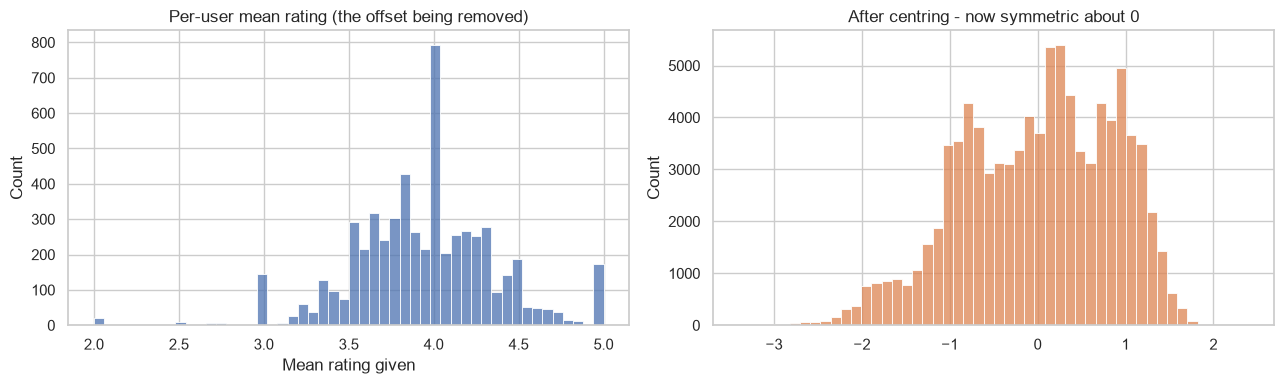

Spread of user means: 2.00 to 5.00


In [4]:
normalized = prep.create_normalized_user_item_matrix(interactions_df)

rated = interactions_df.dropna(subset=['rating'])
user_means = rated.groupby('user_id')['rating'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(user_means, bins=50, ax=axes[0], color='#4C72B0')
axes[0].set_title('Per-user mean rating (the offset being removed)')
axes[0].set_xlabel('Mean rating given')

vals = normalized.to_numpy().flatten()
sns.histplot(vals[vals != 0], bins=50, ax=axes[1], color='#DD8452')
axes[1].set_title('After centring - now symmetric about 0')
plt.tight_layout(); plt.show()

print('Spread of user means: {:.2f} to {:.2f}'.format(user_means.min(), user_means.max()))

## 3. Implicit feedback

Around 31% of interactions carry no star rating at all. Cart and purchase events are recorded for everyone, every time, and are not subject to the self-selection bias of who bothers to leave a review.

In [5]:
implicit = prep.create_implicit_feedback_matrix(interactions_df)

print('Implicit matrix :', implicit.shape)
print('Positive cells  : {:,}'.format(int(implicit.to_numpy().sum())))
print('Rows with no rating: {:.1%}'.format(interactions_df['rating'].isna().mean()))

print('\nCoverage comparison:')
print('  explicit signal available : {:,} interactions'.format(
    int(interactions_df['rating'].notna().sum())))
print('  implicit signal available : {:,} interactions'.format(len(interactions_df)))

Implicit matrix : (5859, 2270)
Positive cells  : 65,715
Rows with no rating: 31.5%

Coverage comparison:
  explicit signal available : 94,824 interactions
  implicit signal available : 138,345 interactions


## 4. Item popularity and long-tail flags

Reindexing against the full catalogue is essential: an item with *zero* interactions never appears in the interaction log, and is precisely the cold-start case that must not be dropped.

In [6]:
item_pop = prep.create_item_popularity_features(interactions_df, items_df)

print('Rows in feature table :', len(item_pop))
print('Items in catalogue    :', len(items_df))
print('Items with 0 events   : {:,}  <- would be lost without reindexing'.format(
    int((item_pop['interaction_count'] == 0).sum())))

item_pop.head()

Rows in feature table : 2500
Items in catalogue    : 2500
Items with 0 events   : 230  <- would be lost without reindexing


,item_id,interaction_count,average_rating,purchase_count,total_revenue,avg_view_time,popularity_ratio,conversion_rate,is_long_tail
0,1,21.0,3.411765,4.0,12967.11,104.047619,0.015251,0.190476,1
1,2,5.0,2.750000,0.0,0.00,58.020000,0.003631,0.000000,1
2,3,0.0,0.000000,0.0,0.00,0.000000,0.000000,0.000000,1
3,4,24.0,3.684211,6.0,40523.28,139.408333,0.017429,0.250000,1
4,5,33.0,4.000000,6.0,6584.67,168.212121,0.023965,0.181818,1


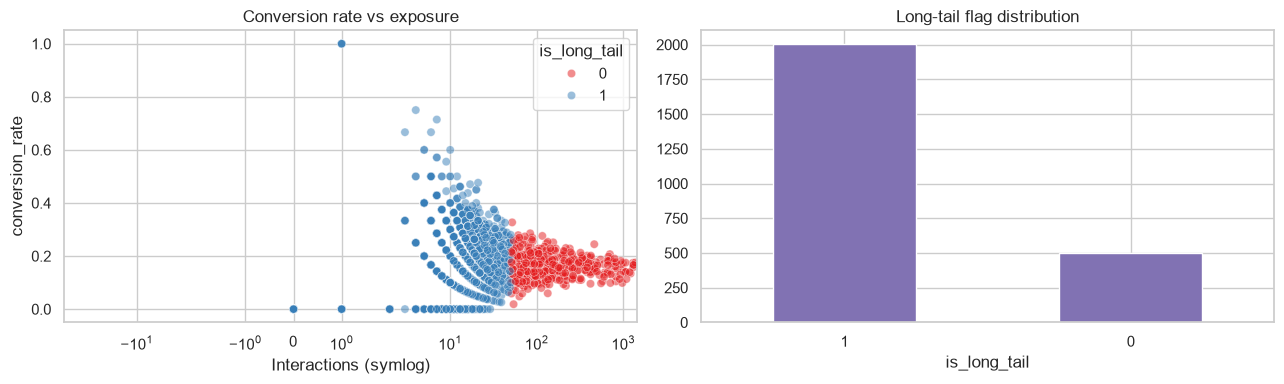

Long-tail items: 2,002 (80.1% of catalogue)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.scatterplot(data=item_pop, x='interaction_count', y='conversion_rate',
                hue='is_long_tail', alpha=0.5, ax=axes[0], palette='Set1')
axes[0].set_xscale('symlog')
axes[0].set_title('Conversion rate vs exposure')
axes[0].set_xlabel('Interactions (symlog)')

item_pop['is_long_tail'].value_counts().plot(kind='bar', ax=axes[1], color='#8172B3')
axes[1].set_title('Long-tail flag distribution')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

print('Long-tail items: {:,} ({:.1%} of catalogue)'.format(
    int(item_pop['is_long_tail'].sum()), item_pop['is_long_tail'].mean()))

**Why conversion rate matters.** Raw interaction count only measures how widely an item was *shown*. An item with modest traffic but a high buy-through rate is genuinely good and deserves promotion; one with heavy traffic and poor conversion is merely over-exposed.

## 5. Item content features

The structured counterpart to the TF-IDF text vectors. Every one of these attributes exists the moment a product is listed, which is what makes a brand-new item recommendable before it has any sales history.

In [8]:
item_content = prep.create_item_content_features(items_df)
print('Item content features:', item_content.shape)
print('\nFeature groups:')
print('  numeric   :', [c for c in item_content.columns if not c.startswith(('category_', 'subcategory_', 'brand_'))])
print('  category  :', sum(c.startswith('category_') for c in item_content.columns))
print('  subcategory:', sum(c.startswith('subcategory_') for c in item_content.columns))
print('  brand     :', sum(c.startswith('brand_') for c in item_content.columns))

Item content features: (2500, 173)

Feature groups:
  numeric   : ['price', 'base_quality', 'price_percentile']
  category  : 10
  subcategory: 80
  brand     : 80


## 6. User profile features

`user_segment` is the field that carries commercial meaning: it is what lets the system make a sensible first recommendation to somebody who has never clicked anything, purely from who they signed up as.

In [9]:
user_profile = prep.create_user_profile_features(users_df)
print('User profile features:', user_profile.shape)
user_profile.iloc[:5, :8]

User profile features: (6000, 35)


,age,user_segment_Budget Shopper,user_segment_Luxury Enthusiast,user_segment_Mainstream Buyer,user_segment_Premium Buyer,user_segment_Value Seeker,preferred_category_Automotive,preferred_category_Beauty & Personal Care
user_id,,,,,,,,
1,0.166667,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.333333,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0.351852,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.074074,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5,0.111111,1.0,0.0,0.0,0.0,0.0,0.0,0.0


## 7. Engagement features

In [10]:
engagement = prep.create_user_engagement_features(interactions_df)
print(engagement[['interaction_count', 'purchase_count', 'total_spend',
                  'conversion_rate']].describe().round(2))

       interaction_count  purchase_count  total_spend  conversion_rate
count            5859.00         5859.00      5859.00          5859.00
mean               23.61            3.88     22829.36             0.17
std                27.71            5.06     56161.61             0.15
min                 1.00            0.00         0.00             0.00
25%                 7.00            1.00       900.18             0.07
50%                15.00            2.00      5510.10             0.15
75%                29.00            5.00     20590.42             0.24
max               201.00           56.00   1187109.96             1.00


## 8. Relevance labels for evaluation

An interaction counts as relevant if the customer rated it at or above 4 **or** purchased it. Including purchases is not optional: a bought-but-unrated item is unambiguous evidence of relevance, and excluding it would understate every model's recall by roughly the share of purchases that go unrated.

In [11]:
labelled = prep.mark_relevant_interactions(interactions_df)

rating_only = (labelled['rating'] >= 4).fillna(False).sum()
combined = labelled['is_relevant'].sum()

print('Relevant by rating alone      : {:,}'.format(int(rating_only)))
print('Relevant by rating OR purchase: {:,}'.format(int(combined)))
print('Additional labels recovered   : {:,} ({:+.1%})'.format(
    int(combined - rating_only), (combined - rating_only) / rating_only))

Relevant by rating alone      : 63,679
Relevant by rating OR purchase: 69,128
Additional labels recovered   : 5,449 (+8.6%)


## Summary

| Artifact | Shape | Consumed by |
|---|---|---|
| `user_item_matrix` | 5,766 x 2,264 | user/item CF, SVD |
| `normalized_user_item_matrix` | 5,766 x 2,264 | SVD |
| `implicit_feedback_matrix` | 5,859 x 2,270 | implicit CF, NCF |
| `item_popularity_features` | 2,500 x 9 | re-ranking, cold-start detection |
| `item_content_features` | 2,500 x 173 | cold-start item scoring |
| `user_profile_features` | 6,000 x 35 | cold-start user scoring |

Note the row counts. The rating matrix has 5,766 users and 2,264 items, but the catalogue has 2,500 and the user base 6,000. That gap **is** the cold-start problem, made explicit.